### Improving on QuickStart Code from PyTorch

In [17]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor

In [18]:
# Define temporary data and dataloader to find mean, std for normalization
temp_data = datasets.FashionMNIST(root="data", train=True, download=True, transform=transforms.ToTensor())
temp_loader = DataLoader(temp_data, batch_size=len(temp_data), shuffle=False)

images, _ = next(iter(temp_loader))
mean = images.mean().item()
std = images.std().item()

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,))
])

In [19]:
training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform,
)

# Download test data from open datasets.
test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform,
)

Dataloader - Wraps an iterable over our dataset and supports automatic batching, sampling, shuffling

In [20]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


In [21]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

Using cuda device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [22]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

# Initialize lists to collect losses and accuracy
train_losses = []
test_losses = []
test_accuracies = []

def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    total_loss = 0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        # Forward pass
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch % 100 == 0:
            current = (batch + 1) * len(X)
            print(f"loss: {loss.item():>7f}  [{current:>5d}/{size:>5d}]")
    
    avg_loss = total_loss / len(dataloader)
    train_losses.append(avg_loss)

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss = 0
    correct = 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    
    avg_loss = test_loss / num_batches
    accuracy = correct / size
    test_losses.append(avg_loss)
    test_accuracies.append(accuracy)

    print(f"Test Error: \n Accuracy: {(100*accuracy):>0.1f}%, Avg loss: {avg_loss:>8f} \n")

In [23]:
epochs = 20
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.301997  [   64/60000]
loss: 2.206545  [ 6464/60000]
loss: 2.100397  [12864/60000]
loss: 2.064568  [19264/60000]
loss: 1.892513  [25664/60000]
loss: 1.804827  [32064/60000]
loss: 1.718455  [38464/60000]
loss: 1.585684  [44864/60000]
loss: 1.534979  [51264/60000]
loss: 1.379393  [57664/60000]
Test Error: 
 Accuracy: 63.8%, Avg loss: 1.368721 

Epoch 2
-------------------------------
loss: 1.403995  [   64/60000]
loss: 1.399836  [ 6464/60000]
loss: 1.135395  [12864/60000]
loss: 1.285900  [19264/60000]
loss: 1.049722  [25664/60000]
loss: 1.087604  [32064/60000]
loss: 1.070182  [38464/60000]
loss: 1.022771  [44864/60000]
loss: 1.062412  [51264/60000]
loss: 0.976799  [57664/60000]
Test Error: 
 Accuracy: 71.0%, Avg loss: 0.942331 

Epoch 3
-------------------------------
loss: 0.952967  [   64/60000]
loss: 1.022087  [ 6464/60000]
loss: 0.754511  [12864/60000]
loss: 0.994184  [19264/60000]
loss: 0.829166  [25664/60000]
loss: 0.863020  [32064/600

Accuracy of 82.8% exceeds the 50% in the original QuickStart resource!

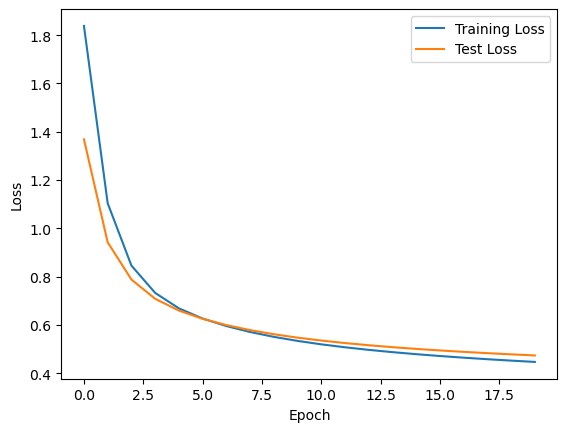

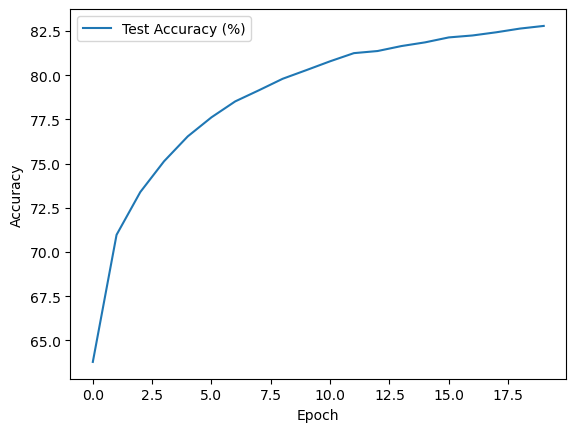

In [24]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label='Training Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.plot([acc * 100 for acc in test_accuracies], label='Test Accuracy (%)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

No overfitting, test loss doesn't increase after some point

Curves stay close to each other similarity in performance in training and testing

Flattens toward end indicates it's approaching optimal performance

Initial loss gap due to model intialization and regularization effects

In [28]:
torch.save(model.state_dict(), "Models/FashionModel82.pth")
print("Saved PyTorch Model State to Models/FashionModel82.pth")

Saved PyTorch Model State to Models/FashionModel82.pth


In [29]:
model = NeuralNetwork().to(device)
model.load_state_dict(torch.load("Models/FashionModel82.pth", weights_only=True))

<All keys matched successfully>

In [30]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

model.eval()
x, y = test_data[0][0], test_data[0][1]
with torch.no_grad():
    x = x.to(device)
    pred = model(x)
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    print(f'Predicted: "{predicted}", Actual: "{actual}"')

Predicted: "Ankle boot", Actual: "Ankle boot"
